# XGBoost Regression with a `log1p` Target

The model is trained on `np.log1p(charges)`. Predictions are converted back to the original scale with `np.expm1`, and all main metrics (RMSE, MAE, R2) are reported on that original `charges` scale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1337 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Train/Test Split and Target Transform

After splitting the data, we transform the training target using `np.log1p` for XGBoost training (`y_train_log`).

In [2]:
from sklearn.model_selection import train_test_split

data_df['smoker_bmi'] = data_df['smoker_encoded'] * data_df['bmi']
data_df['age_squared'] = data_df['age'] ** 2

feature_cols = ['age', 'age_squared', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
                'region_northwest', 'region_southeast', 'region_southwest',
                'smoker_bmi']

X = data_df[feature_cols]
y = data_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1")

Training set: 1069 samples
Test set:     268 samples
Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1


## 2. Model Training (Tuned, Log-Target)

`RandomizedSearchCV` and early stopping use RMSE on **`log1p(charges)`**. Final predictions are then converted with `expm1` so evaluation is easy to interpret in the original dollar scale.

In [3]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Baseline: fit on log1p(charges); predictions back to original scale
baseline_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse',
)
baseline_model.fit(X_train, y_train_log)
y_pred_train_baseline = np.expm1(baseline_model.predict(X_train))
y_pred_test_baseline = np.expm1(baseline_model.predict(X_test))

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

base_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)

param_dist = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    'n_estimators': [300, 500, 800],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
search.fit(X_tr, y_tr)

tuned_params = search.best_params_.copy()

monitoring_model = XGBRegressor(
    **tuned_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
)
monitoring_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)

evals_result = monitoring_model.evals_result()
tuned_n_estimators = int(monitoring_model.best_iteration + 1)

model = XGBRegressor(
    **{k: v for k, v in tuned_params.items() if k != 'n_estimators'},
    n_estimators=tuned_n_estimators,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)
model.fit(X_train, y_train_log)

y_pred_train = np.expm1(model.predict(X_train))
y_pred_test = np.expm1(model.predict(X_test))

print('XGBoost tuning completed (target: log1p(charges)).')
print('Metrics in the next section use original scale (expm1).')
print('Best params:', tuned_params)
print(f'Best boosting rounds from early stopping: {tuned_n_estimators}')

XGBoost tuning completed (target: log1p(charges)).
Metrics in the next section use original scale (expm1).
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best boosting rounds from early stopping: 500


## 3. Model Evaluation (R2, RMSE, MAE on Original `charges`)

Here, original `y_train` and `y_test` are compared against predictions after applying `expm1`.

In [4]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Tuned model metrics (original dollar scale)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Baseline metrics (before tuning)
r2_train_base = r2_score(y_train, y_pred_train_baseline)
r2_test_base = r2_score(y_test, y_pred_test_baseline)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
mae_train_base = mean_absolute_error(y_train, y_pred_train_baseline)
mae_test_base = mean_absolute_error(y_test, y_pred_test_baseline)

metrics = pd.DataFrame({
    'Metric': ['R2', 'RMSE', 'MAE'],
    'Train': [r2_train, rmse_train, mae_train],
    'Test': [r2_test, rmse_test, mae_test]
})

comparison_before_after = pd.DataFrame([
    {
        'Model': 'Baseline',
        'R2_train': r2_train_base,
        'R2_test': r2_test_base,
        'RMSE_train': rmse_train_base,
        'RMSE_test': rmse_test_base,
        'MAE_train': mae_train_base,
        'MAE_test': mae_test_base,
    },
    {
        'Model': 'Tuned',
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
    }
])

print('Model performance (original charges; y vs expm1 predictions):\n')
print(metrics.to_string(index=False, formatters={'Train': '{:,.4f}'.format, 'Test': '{:,.4f}'.format}))

print('\nBefore vs After Tuning:\n')
display(comparison_before_after.style.format({
    'R2_train': '{:.4f}', 'R2_test': '{:.4f}',
    'RMSE_train': '{:,.0f}', 'RMSE_test': '{:,.0f}',
    'MAE_train': '{:,.0f}', 'MAE_test': '{:,.0f}'
}))

Model performance (original charges; y vs expm1 predictions):

Metric      Train       Test
    R2     0.8607     0.8958
  RMSE 4,367.1890 4,376.4102
   MAE 1,912.2404 2,003.3888

Before vs After Tuning:



,Model,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test
0,Baseline,0.9257,0.7575,"3,189","6,675","1,461","2,824"
1,Tuned,0.8607,0.8958,"4,367","4,376","1,912","2,003"


## 3b. Cross-Validation (5-Fold, Metrics on Original Scale)

`TransformedTargetRegressor` handles the `log1p`/`expm1` mapping, so RMSE/MAE/R2 scores stay comparable with Section 3.

In [5]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = TransformedTargetRegressor(
    regressor=XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=42,
        objective='reg:squarederror',
        eval_metric='rmse',
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

cv_scores = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'  # optional overview metric
    },
    return_train_score=False,
    n_jobs=1
)

cv_result = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 6)],
    'RMSE': -cv_scores['test_rmse'],
    'MAE': -cv_scores['test_mae'],
    'R2 (optional)': cv_scores['test_r2']
})

cv_summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2 (optional)'],
    'Mean (5-Fold CV)': [
        cv_result['RMSE'].mean(),
        cv_result['MAE'].mean(),
        cv_result['R2 (optional)'].mean()
    ],
    'Std Dev': [
        cv_result['RMSE'].std(ddof=1),
        cv_result['MAE'].std(ddof=1),
        cv_result['R2 (optional)'].std(ddof=1)
    ]
})

print('Per-fold CV scores (RMSE-focused):')
display(cv_result.style.format({'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'R2 (optional)': '{:.4f}'}))

print('\nCV summary (mean ± std):')
display(cv_summary.style.format({'Mean (5-Fold CV)': '{:,.4f}', 'Std Dev': '{:,.4f}'}))

Per-fold CV scores (RMSE-focused):


,Fold,RMSE,MAE,R2 (optional)
0,Fold 1,"4,894.98","2,419.41",0.8696
1,Fold 2,"5,248.35","2,424.42",0.8107
2,Fold 3,"4,785.20","2,379.04",0.8378
3,Fold 4,"4,350.47","2,151.52",0.8403
4,Fold 5,"4,568.10","2,295.10",0.8533



CV summary (mean ± std):


,Metric,Mean (5-Fold CV),Std Dev
0,RMSE,"4,769.4195",339.6441
1,MAE,"2,333.8981",114.3576
2,R2 (optional),0.8424,0.0217


## 4. Feature Importance (XGBoost)

Feature Importance (XGBoost):

  smoker_encoded            :       0.4043
  smoker_bmi                :       0.2594
  age                       :       0.1156
  age_squared               :       0.1130
  children                  :       0.0437
  bmi                       :       0.0184
  region_northwest          :       0.0131
  gender_encoded            :       0.0129
  region_southwest          :       0.0100
  region_southeast          :       0.0096


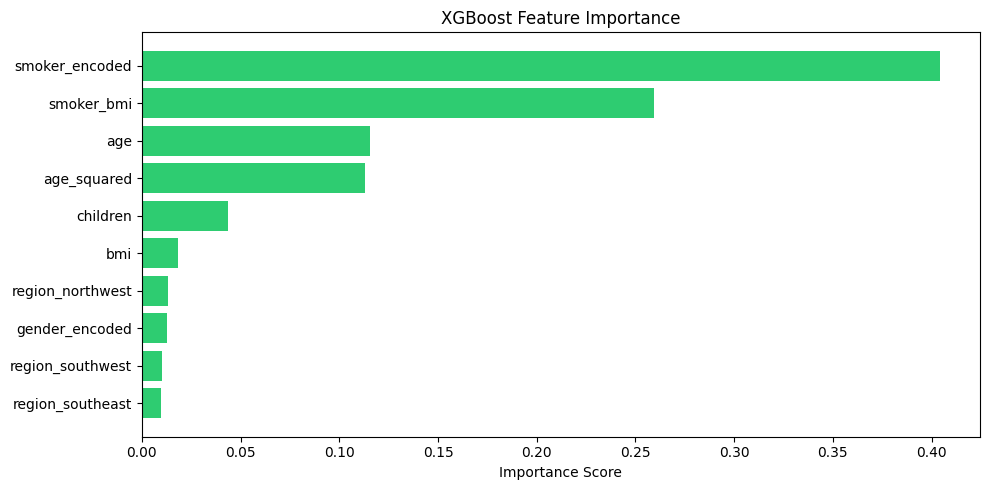

In [6]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (XGBoost):\n")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Importance']:>12.4f}")

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ecc71')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual analysis (original `charges`)

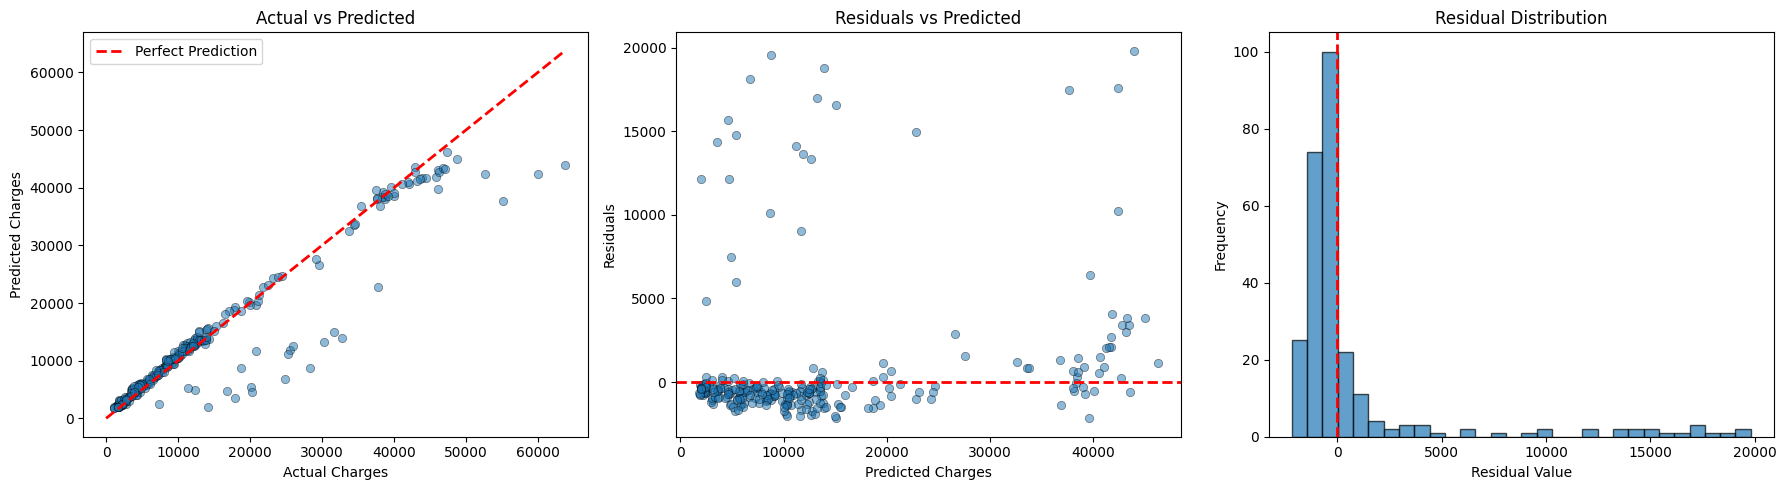

In [7]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 5b. Inspect Rows with the Largest Residuals and Export to CSV

The table below sorts the **test set** by `|y_actual - y_pred|` (original scale). The `residual_log` column compares the log-space target (`log1p`) against the model's raw output. The CSV file stores the **top N** rows for spreadsheet review.

In [8]:
TOP_N = 25
OUT_CSV = "xgboost_log_reg_top_residuals_test.csv"

inspect_df = X_test.copy()
inspect_df.insert(0, "original_row_index", X_test.index.to_numpy())
inspect_df["y_actual"] = np.asarray(y_test)
inspect_df["y_pred"] = np.asarray(y_pred_test)
inspect_df["residual"] = inspect_df["y_actual"] - inspect_df["y_pred"]
inspect_df["abs_error"] = inspect_df["residual"].abs()
inspect_df["pct_abs_error"] = (
    inspect_df["abs_error"] / inspect_df["y_actual"].replace(0, np.nan) * 100
)

y_log_actual = np.log1p(inspect_df["y_actual"].to_numpy(dtype=float))
y_log_pred = model.predict(X_test)
inspect_df["residual_log"] = y_log_actual - y_log_pred
inspect_df["abs_error_log"] = np.abs(inspect_df["residual_log"])

inspect_sorted = inspect_df.sort_values("abs_error", ascending=False)
display(
    inspect_sorted.head(TOP_N).style.format(
        {
            "y_actual": "{:,.2f}",
            "y_pred": "{:,.2f}",
            "residual": "{:,.2f}",
            "abs_error": "{:,.2f}",
            "pct_abs_error": "{:.2f}",
            "residual_log": "{:.4f}",
            "abs_error_log": "{:.4f}",
        },
        na_rep="—",
    )
)

inspect_sorted.head(TOP_N).to_csv(OUT_CSV, index=False)
print(f"Exported top {TOP_N} rows by |residual| (original scale) to: {OUT_CSV}")

,original_row_index,age,age_squared,bmi,children,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,smoker_bmi,y_actual,y_pred,residual,abs_error,pct_abs_error,residual_log,abs_error_log
543,543,54,2916,47.315000,0,1,1,0.000000,1.000000,0.000000,47.315000,"63,770.43","43,954.72","19,815.71","19,815.71",31.07,0.3721,0.3721
986,986,45,2025,27.645000,1,1,0,1.000000,0.000000,0.000000,0.000000,"28,340.19","8,797.64","19,542.55","19,542.55",68.96,1.1697,1.1697
128,128,32,1024,17.765000,2,1,1,1.000000,0.000000,0.000000,17.765000,"32,734.19","13,951.12","18,783.07","18,783.07",57.38,0.8528,0.8528
636,636,35,1225,38.095000,2,1,0,0.000000,0.000000,0.000000,0.000000,"24,915.05","6,779.31","18,135.73","18,135.73",72.79,1.3015,1.3015
1229,1229,52,2704,34.485000,3,0,1,1.000000,0.000000,0.000000,34.485000,"60,021.40","42,438.52","17,582.88","17,582.88",29.29,0.3466,0.3466
818,818,33,1089,35.530000,0,1,1,1.000000,0.000000,0.000000,35.530000,"55,135.40","37,643.07","17,492.34","17,492.34",31.73,0.3816,0.3816
115,115,60,3600,28.595000,0,0,0,0.000000,0.000000,0.000000,0.000000,"30,260.00","13,260.64","16,999.35","16,999.35",56.18,0.8250,0.8250
573,573,62,3844,36.860000,1,1,0,0.000000,0.000000,0.000000,0.000000,"31,620.00","15,055.27","16,564.73","16,564.73",52.39,0.7420,0.7420
291,291,29,841,29.640000,1,0,0,0.000000,0.000000,0.000000,0.000000,"20,277.81","4,631.43","15,646.38","15,646.38",77.16,1.4765,1.4765
1302,1302,43,1849,27.800000,0,0,1,0.000000,0.000000,1.000000,27.800000,"37,829.72","22,861.87","14,967.85","14,967.85",39.57,0.5036,0.5036


Exported top 25 rows by |residual| (original scale) to: xgboost_log_reg_top_residuals_test.csv


## 6. Training Monitoring (Learning Curve, RMSE in **log1p** Space)

This curve uses the same scale as early stopping. For business-facing interpretation, compare it with Section 3 metrics on the original scale.

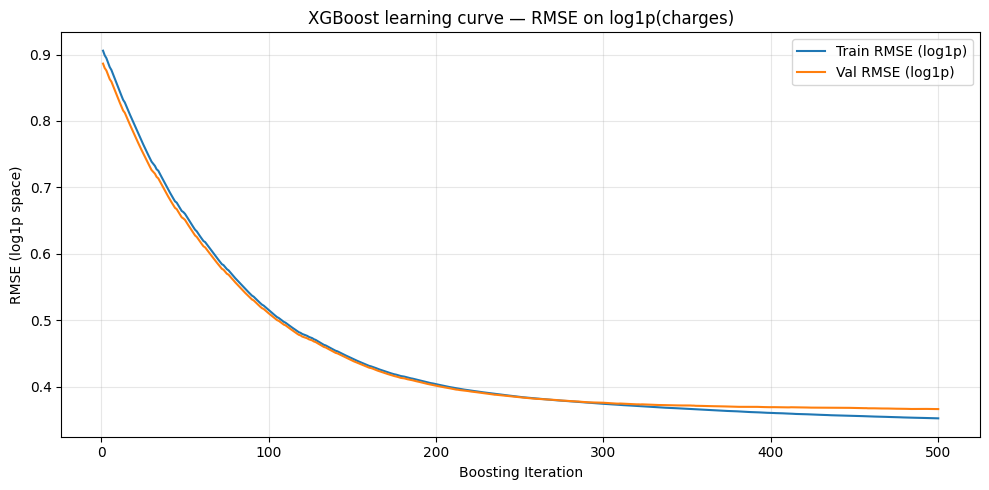

Best val RMSE (log1p) during monitoring: 0.3661 at round 500
Final train-val RMSE gap (log1p): 0.0139
No strong overfitting signal from train-val RMSE gap (log1p).


In [9]:
# Learning curve: RMSE is on log1p(target) — same scale as early stopping
train_rmse_curve = evals_result['validation_0']['rmse']
test_rmse_curve = evals_result['validation_1']['rmse']

rounds = range(1, len(train_rmse_curve) + 1)

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_rmse_curve, label='Train RMSE (log1p)')
plt.plot(rounds, test_rmse_curve, label='Val RMSE (log1p)')
plt.xlabel('Boosting Iteration')
plt.ylabel('RMSE (log1p space)')
plt.title('XGBoost learning curve — RMSE on log1p(charges)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_round = int(np.argmin(test_rmse_curve)) + 1
best_test_rmse_curve = float(np.min(test_rmse_curve))
final_gap = float(test_rmse_curve[-1] - train_rmse_curve[-1])

print(f'Best val RMSE (log1p) during monitoring: {best_test_rmse_curve:,.4f} at round {best_round}')
print(f'Final train-val RMSE gap (log1p): {final_gap:,.4f}')
if final_gap > 0.08:
    print('Possible overfitting in log space: val RMSE notably above train RMSE.')
else:
    print('No strong overfitting signal from train-val RMSE gap (log1p).')

## 7. Export Trained model to Core ML

In [10]:
# Export trained XGBoost model to ONNX
# Output file: model.onnx
# Note: this model predicts in log space (log1p(charges)).

from pathlib import Path

try:
    from onnxmltools import convert_xgboost
    from onnxmltools.convert.common.data_types import FloatTensorType
except ImportError as e:
    raise ImportError(
        "onnxmltools is not installed. Install it first, e.g. `pip install onnxmltools onnx`."
    ) from e

if 'model' not in globals():
    raise RuntimeError("`model` is not found. Run training cells first.")
if 'feature_cols' not in globals():
    raise RuntimeError("`feature_cols` is not found. Run feature preparation cells first.")

n_features = len(feature_cols)
initial_types = [('input', FloatTensorType([None, n_features]))]

# onnxmltools expects XGBoost split names like f0, f1, ...
# while our model was trained with column names (e.g., smoker_bmi).
# Remap feature names on the booster before conversion.
booster = model.get_booster()
booster.feature_names = [f"f{i}" for i in range(n_features)]

onnx_model = convert_xgboost(booster, initial_types=initial_types)

out_path = Path('model.onnx')
with open(out_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())

print(f"Saved ONNX model to: {out_path.resolve()}")
print("Note: model output is in log space (log1p). Apply expm1 to recover charges scale.")
print("Input order must follow feature_cols exactly.")

Saved ONNX model to: /Users/ameliacitra/Documents/AI-ML/C1-Tabular/model.onnx
Note: model output is in log space (log1p). Apply expm1 to recover charges scale.
Input order must follow feature_cols exactly.
